<span style="color:pink; font-size:20px;">File to get plots for Ergotropic Changes vs Change in Correlation Measures of Initial State.</span>
<!-- <span style="color:yellow; font-size:15px;">vs_neg_diff.ipynb</span> -->

In [ ]:
# Import necessary libraries and functions
import numpy as np
import matplotlib.pyplot as plt
from state_gen import generate_state
from energy import energy, passive_energy_g, passive_energy_l
from local_to import qubit_ham, sho_ham, bath_gibbs_states, LTO_step, sys_gibbs_states
from unitary import deg_unitary
from lin_alg import negativity, partial_trace, vn_entropy, rel_entropy, passive_state, mutual_info, correlations
np.set_printoptions(linewidth=np.inf, precision=4, suppress=True)

def fmt(M): return np.array2string(M, precision=4, suppress_small=True, floatmode='fixed', max_line_width=80)

In [ ]:
# Initial default parameters and settings

# Inverse temperatures
beta_a=1.0
beta_b=0.9

# Parameters for Degenerate Hamiltonians
bath_dim = 10
w1 = w2 = 0.0001 # Qubit frequencies
omega_a = omega_b = 0.0001 # Harmonic oscillator frequencies for bath

# State parameters
a = 0.8
p = 0.5
n_terms = 4
N = np.sqrt(a * (1 - a))

kind_dict = {
    1: "product",
    2: "separable",
    3: "schmidt_ent",
    4: "pure_ent",
    5: "werner",
    6: "mixed_ent",
    7: "random"
}

In [3]:
def simulate_and_plot(kind="product", n_samples=200, corr_plot=False):

    neg_list, mi_list, cl_corr_list, disc_list = [], [], [], []
    Rg_lto, Rl_lto, R_gap = [], [], []
    gbound_list = []

    # ----- Initial state -----
    rho12 = generate_state(kind, a=a, n_terms=n_terms, p=p)
    print(f"Initial state:\n{rho12}")

    # ---- reduced states ----
    rho1 = partial_trace(rho12, sys=1)
    rho2 = partial_trace(rho12, sys=0)
    pass_rho_1 = passive_state(rho1)
    pass_rho_2 = passive_state(rho2)

    Hs1 = qubit_ham(w1)
    Hs2 = qubit_ham(w2)
    Hb1 = sho_ham(bath_dim, omega_a)
    Hb2 = sho_ham(bath_dim, omega_b)

    # ----- initial observables ----
    neg_rho = negativity(rho12)
    mi_rho = mutual_info(rho12)
    cl_corr_rho, disc_rho = correlations(rho12)

    E0 = energy(rho12, w1, w2)
    Rg0 = E0 - passive_energy_g(rho12, w1, w2)
    Rl0 = E0 - passive_energy_l(rho12, w1, w2)

    print(f"Initial negativity: {neg_rho:.4f}",)
    print(f"Initial classical correlations: {cl_corr_rho:.4f}",)
    print(f"Initial quantum discord: {disc_rho:.4f}",)
    print(f"Initial mutual information: {mi_rho:.4f}",)


    # ----- Baths (precompute once) -----
    gamma_a, gamma_b = bath_gibbs_states(beta_a, beta_b, bath_dim=bath_dim, omega_a=omega_a, omega_b=omega_b)
    gibbs_a, gibbs_b = sys_gibbs_states(beta_a, beta_b, w1, w2)

    # ---- local bound ----
    bound_l = (rel_entropy(pass_rho_1, gibbs_a)/beta_a) + (rel_entropy(pass_rho_2, gibbs_b)/beta_b)

    # ----- Sampling loop -----
    for _ in range(n_samples):

        Ua = deg_unitary(Hs1, Hb1)
        Ub = deg_unitary(Hs2, Hb2)

        sigma, _, _ = LTO_step(rho12, gamma_a, gamma_b, Ua, Ub)

        # ---- observables ----
        neg_list.append(negativity(sigma))
        mi_list.append(mutual_info(sigma))

        if corr_plot:
            cl_corr_sigma, disc_sigma = correlations(sigma)
            cl_corr_list.append(cl_corr_rho - cl_corr_sigma)
            disc_list.append(disc_rho - disc_sigma)

        E_sigma = energy(sigma, w1, w2)
        Rg = E_sigma - passive_energy_g(sigma, w1, w2)
        Rl = E_sigma - passive_energy_l(sigma, w1, w2)

        Rg_lto.append(Rg)
        Rl_lto.append(Rl)
        R_gap.append(Rg - Rl)

        # ---- reduced states ----
        sigma1 = partial_trace(sigma, sys=1)
        sigma2 = partial_trace(sigma, sys=0)

        # ---- global correction term ----
        local_term = (1/beta_a) * (vn_entropy(sigma1) - vn_entropy(rho1)) + (1/beta_b) * (vn_entropy(sigma2) - vn_entropy(rho2))
        energy_term = - passive_energy_g(rho12, w1, w2) + passive_energy_g(sigma, w1, w2)
        bound_g = energy_term + local_term

        gbound_list.append(bound_g)

    return (rho12, neg_rho, mi_rho, Rg0, Rl0, neg_list, mi_list, cl_corr_list, disc_list, Rg_lto, Rl_lto, R_gap, gbound_list, bound_l)

In [4]:
def plot_lto_results(
    neg_rho, mi_rho, Rg0, Rl0,
    neg_list, mi_list, cl_corr_list, disc_list, 
    Rg_lto, Rl_lto, R_gap, gbound_list, bound_l,
    colors=None,
    marker_size=25,
    alpha=0.5
):
    """
    3×2 visualization of LTO ergotropy behaviour.
    """

    if colors is None:
        colors = {
            "global": "tab:blue",
            "local": "tab:orange",
            "gap": "tab:green",
            "gbound": "tab:red",
            "lbound": "tab:purple"
        }

    # Convert to arrays
    neg_list = np.array(neg_list)
    mi_list = np.array(mi_list)
    Rg_lto = np.array(Rg_lto)
    Rl_lto = np.array(Rl_lto)
    R_gap = np.array(R_gap)
    gbound_list = np.array(gbound_list)
    cl_corr = np.array(cl_corr_list)
    disc = np.array(disc_list)

    ΔN = neg_rho - neg_list
    ΔI = mi_rho - mi_list
    ΔRg = Rg_lto - Rg0
    ΔRl = Rl_lto - Rl0

    fig, axs = plt.subplots(7, 2, figsize=(15, 30))

    # ---------------- Row 1 ----------------

    # Global ergotropy
    axs[0,0].scatter(ΔN, Rg_lto, s=marker_size,
                     color=colors["global"], alpha=alpha, label="Rg after LTO")
    axs[0,0].axhline(Rg0, linestyle="--", color="black", label="Initial Rg")
    axs[0,0].set_title("Global ergotropy vs ΔN")
    axs[0,0].set_xlabel("ΔN")
    axs[0,0].set_ylabel("Rg")
    axs[0,0].legend()
    axs[0,0].grid(True)

    # Global ergotropy
    axs[0,1].scatter(ΔI, Rg_lto, s=marker_size,
                     color=colors["global"], alpha=alpha, label="Rg after LTO")
    axs[0,1].axhline(Rg0, linestyle="--", color="black", label="Initial Rg")
    axs[0,1].set_title("Global ergotropy vs ΔI")
    axs[0,1].set_xlabel("ΔI")
    axs[0,1].set_ylabel("Rg")
    axs[0,1].legend()
    axs[0,1].grid(True)

    # ---------------- Row 2 ----------------

    # Local ergotropy
    axs[1,0].scatter(ΔN, Rl_lto, s=marker_size,
                     color=colors["local"], alpha=alpha, label="Rl after LTO")
    axs[1,0].axhline(Rl0, linestyle="--", color="black", label="Initial Rl")
    axs[1,0].set_title("Local ergotropy vs ΔN")
    axs[1,0].set_xlabel("ΔN")
    axs[1,0].set_ylabel("Rl")
    axs[1,0].legend()
    axs[1,0].grid(True)

    # Local ergotropy
    axs[1,1].scatter(ΔI, Rl_lto, s=marker_size,
                     color=colors["local"], alpha=alpha, label="Rl after LTO")
    axs[1,1].axhline(Rl0, linestyle="--", color="black", label="Initial Rl")
    axs[1,1].set_title("Local ergotropy vs ΔI")
    axs[1,1].set_xlabel("ΔI")
    axs[1,1].set_ylabel("Rl")
    axs[1,1].legend()
    axs[1,1].grid(True)

    # ---------------- Row 3 ----------------

    # ΔRg with bound
    axs[2,0].scatter(ΔN, ΔRg, s=marker_size,
                     color=colors["global"], alpha=alpha, label="ΔRg")
    axs[2,0].scatter(ΔN, gbound_list, s=marker_size,
                     color=colors["gbound"], alpha=alpha, label="Global bound")
    axs[2,0].set_title("ΔRg vs ΔN")
    axs[2,0].set_xlabel("ΔN")
    axs[2,0].set_ylabel("ΔRg")
    axs[2,0].legend()
    axs[2,0].grid(True)

    # ΔRg with bound
    axs[2,1].scatter(ΔI, ΔRg, s=marker_size,
                     color=colors["global"], alpha=alpha, label="ΔRg")
    axs[2,1].scatter(ΔI, gbound_list, s=marker_size,
                     color=colors["gbound"], alpha=alpha, label="Global bound")
    axs[2,1].set_title("ΔRg vs ΔI")
    axs[2,1].set_xlabel("ΔI")
    axs[2,1].set_ylabel("ΔRg")
    axs[2,1].legend()
    axs[2,1].grid(True)

    # ---------------- Row 4 ----------------

    # ΔRl with bound
    axs[3,0].scatter(ΔN, ΔRl, s=marker_size,
                     color=colors["local"], alpha=alpha, label="ΔRl")
    axs[3,0].axhline(bound_l, linestyle="--", color="purple", label="Local bound")
    axs[3,0].set_title("ΔRl vs ΔN")
    axs[3,0].set_xlabel("ΔN")
    axs[3,0].set_ylabel("ΔRl")
    axs[3,0].legend()
    axs[3,0].grid(True)

    # ΔRl with bound
    axs[3,1].scatter(ΔI, ΔRl, s=marker_size,
                     color=colors["local"], alpha=alpha, label="ΔRl")
    axs[3,1].axhline(bound_l, linestyle="--", color="purple", label="Local bound")
    axs[3,1].set_title("ΔRl vs ΔI")
    axs[3,1].set_xlabel("ΔI")
    axs[3,1].set_ylabel("ΔRl")
    axs[3,1].legend()
    axs[3,1].grid(True)

    # --------------- Row 5 ------------------------

    # Gap
    axs[4,0].scatter(ΔN, R_gap, s=marker_size,
                     color=colors["gap"], alpha=alpha, label="Rg − Rl")
    axs[4,0].axhline(Rg0 - Rl0, linestyle="--", color="black", label="Initial gap")
    axs[4,0].set_title("Ergotropy gap vs ΔN")
    axs[4,0].set_xlabel("ΔN")
    axs[4,0].set_ylabel("Gap")
    axs[4,0].legend()
    axs[4,0].grid(True)

    # Gap
    axs[4,1].scatter(ΔI, R_gap, s=marker_size,
                     color=colors["gap"], alpha=alpha, label="Rg − Rl")
    axs[4,1].axhline(Rg0 - Rl0, linestyle="--", color="black", label="Initial gap")
    axs[4,1].set_title("Ergotropy gap vs ΔI")
    axs[4,1].set_xlabel("ΔI")
    axs[4,1].set_ylabel("Gap")
    axs[4,1].legend()
    axs[4,1].grid(True)


    # --------------- Row 6 ------------------------
    lims2 = [min(ΔN.min(), ΔI.min()) - 0.01,
            max(ΔN.max(), ΔI.max()) + 0.01]

    for col, (c_arr, c_label, ttl) in enumerate([
        (ΔRg, r"$\Delta R_g$", "ΔN vs ΔI (colored by ΔRg)"),
        (ΔRl, r"$\Delta R_l$", "ΔN vs ΔI (colored by ΔRl)"),
    ]):
        ax  = axs[5, col]
        sc  = ax.scatter(ΔN, ΔI, c=c_arr, cmap='viridis',
                        s=marker_size, alpha=alpha,
                        linewidths=0.4, edgecolors='white', zorder=3)
        cbar = fig.colorbar(sc, ax=ax, pad=0.02)
        cbar.set_label(c_label, fontsize=10)
        cbar.ax.tick_params(labelsize=8)
        ax.plot(lims2, lims2, color='#BDBDBD', linewidth=0.9,
                linestyle='--', zorder=1, label=r"$\Delta N = \Delta I$")
        ax.axvline(0, color='#BDBDBD', linewidth=0.8, linestyle=':', zorder=1)
        ax.set_xlim(lims2);  ax.set_ylim(lims2)
        ax.set_xlabel(r"$\Delta N$",  fontsize=10)
        ax.set_ylabel(r"$\Delta I$",  fontsize=10)
        ax.set_title(ttl,             fontsize=10)
        ax.legend(fontsize=8, frameon=True)
        ax.grid(True)

    if disc.size > 0:
        # --------------- Row 7 ------------------------
        lims2 = [min(cl_corr.min(), disc.min()) - 0.01,
                max(cl_corr.max(), disc.max()) + 0.01]

        for col, (c_arr, c_label, ttl) in enumerate([
            (ΔRg, r"$\Delta R_g$", "ΔC vs ΔQ (colored by ΔRg)"),
            (ΔRl, r"$\Delta R_l$", "ΔC vs ΔQ (colored by ΔRl)"),
        ]):
            ax  = axs[6, col]
            sc  = ax.scatter(cl_corr, disc, c=c_arr, cmap='viridis',
                            s=marker_size, alpha=alpha,
                            linewidths=0.4, edgecolors='white', zorder=3)
            cbar = fig.colorbar(sc, ax=ax, pad=0.02)
            cbar.set_label(c_label, fontsize=10)
            cbar.ax.tick_params(labelsize=8)
            ax.plot(lims2, lims2, color='#BDBDBD', linewidth=0.9,
                    linestyle='--', zorder=1, label=r"$\Delta C = \Delta Q$")
            ax.axvline(0, color='#BDBDBD', linewidth=0.8, linestyle=':', zorder=1)
            ax.set_xlim(lims2);  ax.set_ylim(lims2)
            ax.set_xlabel(r"$\Delta C$",  fontsize=10)
            ax.set_ylabel(r"$\Delta Q$",  fontsize=10)
            ax.set_title(ttl,             fontsize=10)
            ax.legend(fontsize=8, frameon=True)
            ax.grid(True)

    else: 
        axs[6, 0].axis('off')
        axs[6, 1].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# Defining New Parameters

# Parameters for Degenerate Hamiltonians
w1=1.0
w2=2.0
# w3=1.5 #1.0 #1.5
# w4=0.5 #2.0 #0.5
w3 = 1.0
w4 = 2.0

# Inverse temperatures
beta_a=1.0
beta_b=2.0

# State parameters
a = 0.8
p = 0.5
n_terms = 4
N = np.sqrt(a * (1 - a))
np.set_printoptions(precision=4, suppress=True)

kind_dict = {
    1: "product",
    2: "separable",
    3: "schmidt_ent",
    4: "pure_ent",
    5: "werner",
    6: "mixed_ent",
    7: "random"
}

Initial state:
[[ 0.117 -0.j     -0.0625-0.0082j -0.1013+0.2814j  0.0987-0.0122j]
 [-0.0625+0.0082j  0.0339+0.j      0.0343-0.1574j -0.0518+0.0135j]
 [-0.1013-0.2814j  0.0343+0.1574j  0.7645-0.j     -0.1148-0.2268j]
 [ 0.0987+0.0122j -0.0518-0.0135j -0.1148+0.2268j  0.0845+0.j    ]]


Optimizing classical correlations: 100%|██████████| 200/200 [00:00<00:00, 518.40trial/s]


Initial negativity: 0.1332
Initial classical correlations: 0.0904
Initial quantum discord: 0.0904
Initial mutual information: 0.1809


Optimizing classical correlations: 100%|██████████| 200/200 [00:02<00:00, 98.72trial/s] 


rho12: 
[[ 0.117 -0.j     -0.0625-0.0082j -0.1013+0.2814j  0.0987-0.0122j]
 [-0.0625+0.0082j  0.0339+0.j      0.0343-0.1574j -0.0518+0.0135j]
 [-0.1013-0.2814j  0.0343+0.1574j  0.7645-0.j     -0.1148-0.2268j]
 [ 0.0987+0.0122j -0.0518-0.0135j -0.1148+0.2268j  0.0845+0.j    ]]
[[ 0.1509+0.j     -0.1532+0.2949j]
 [-0.1532-0.2949j  0.8491-0.j    ]]
[[ 0.8815-0.j     -0.1773-0.2351j]
 [-0.1773+0.2351j  0.1185+0.j    ]]


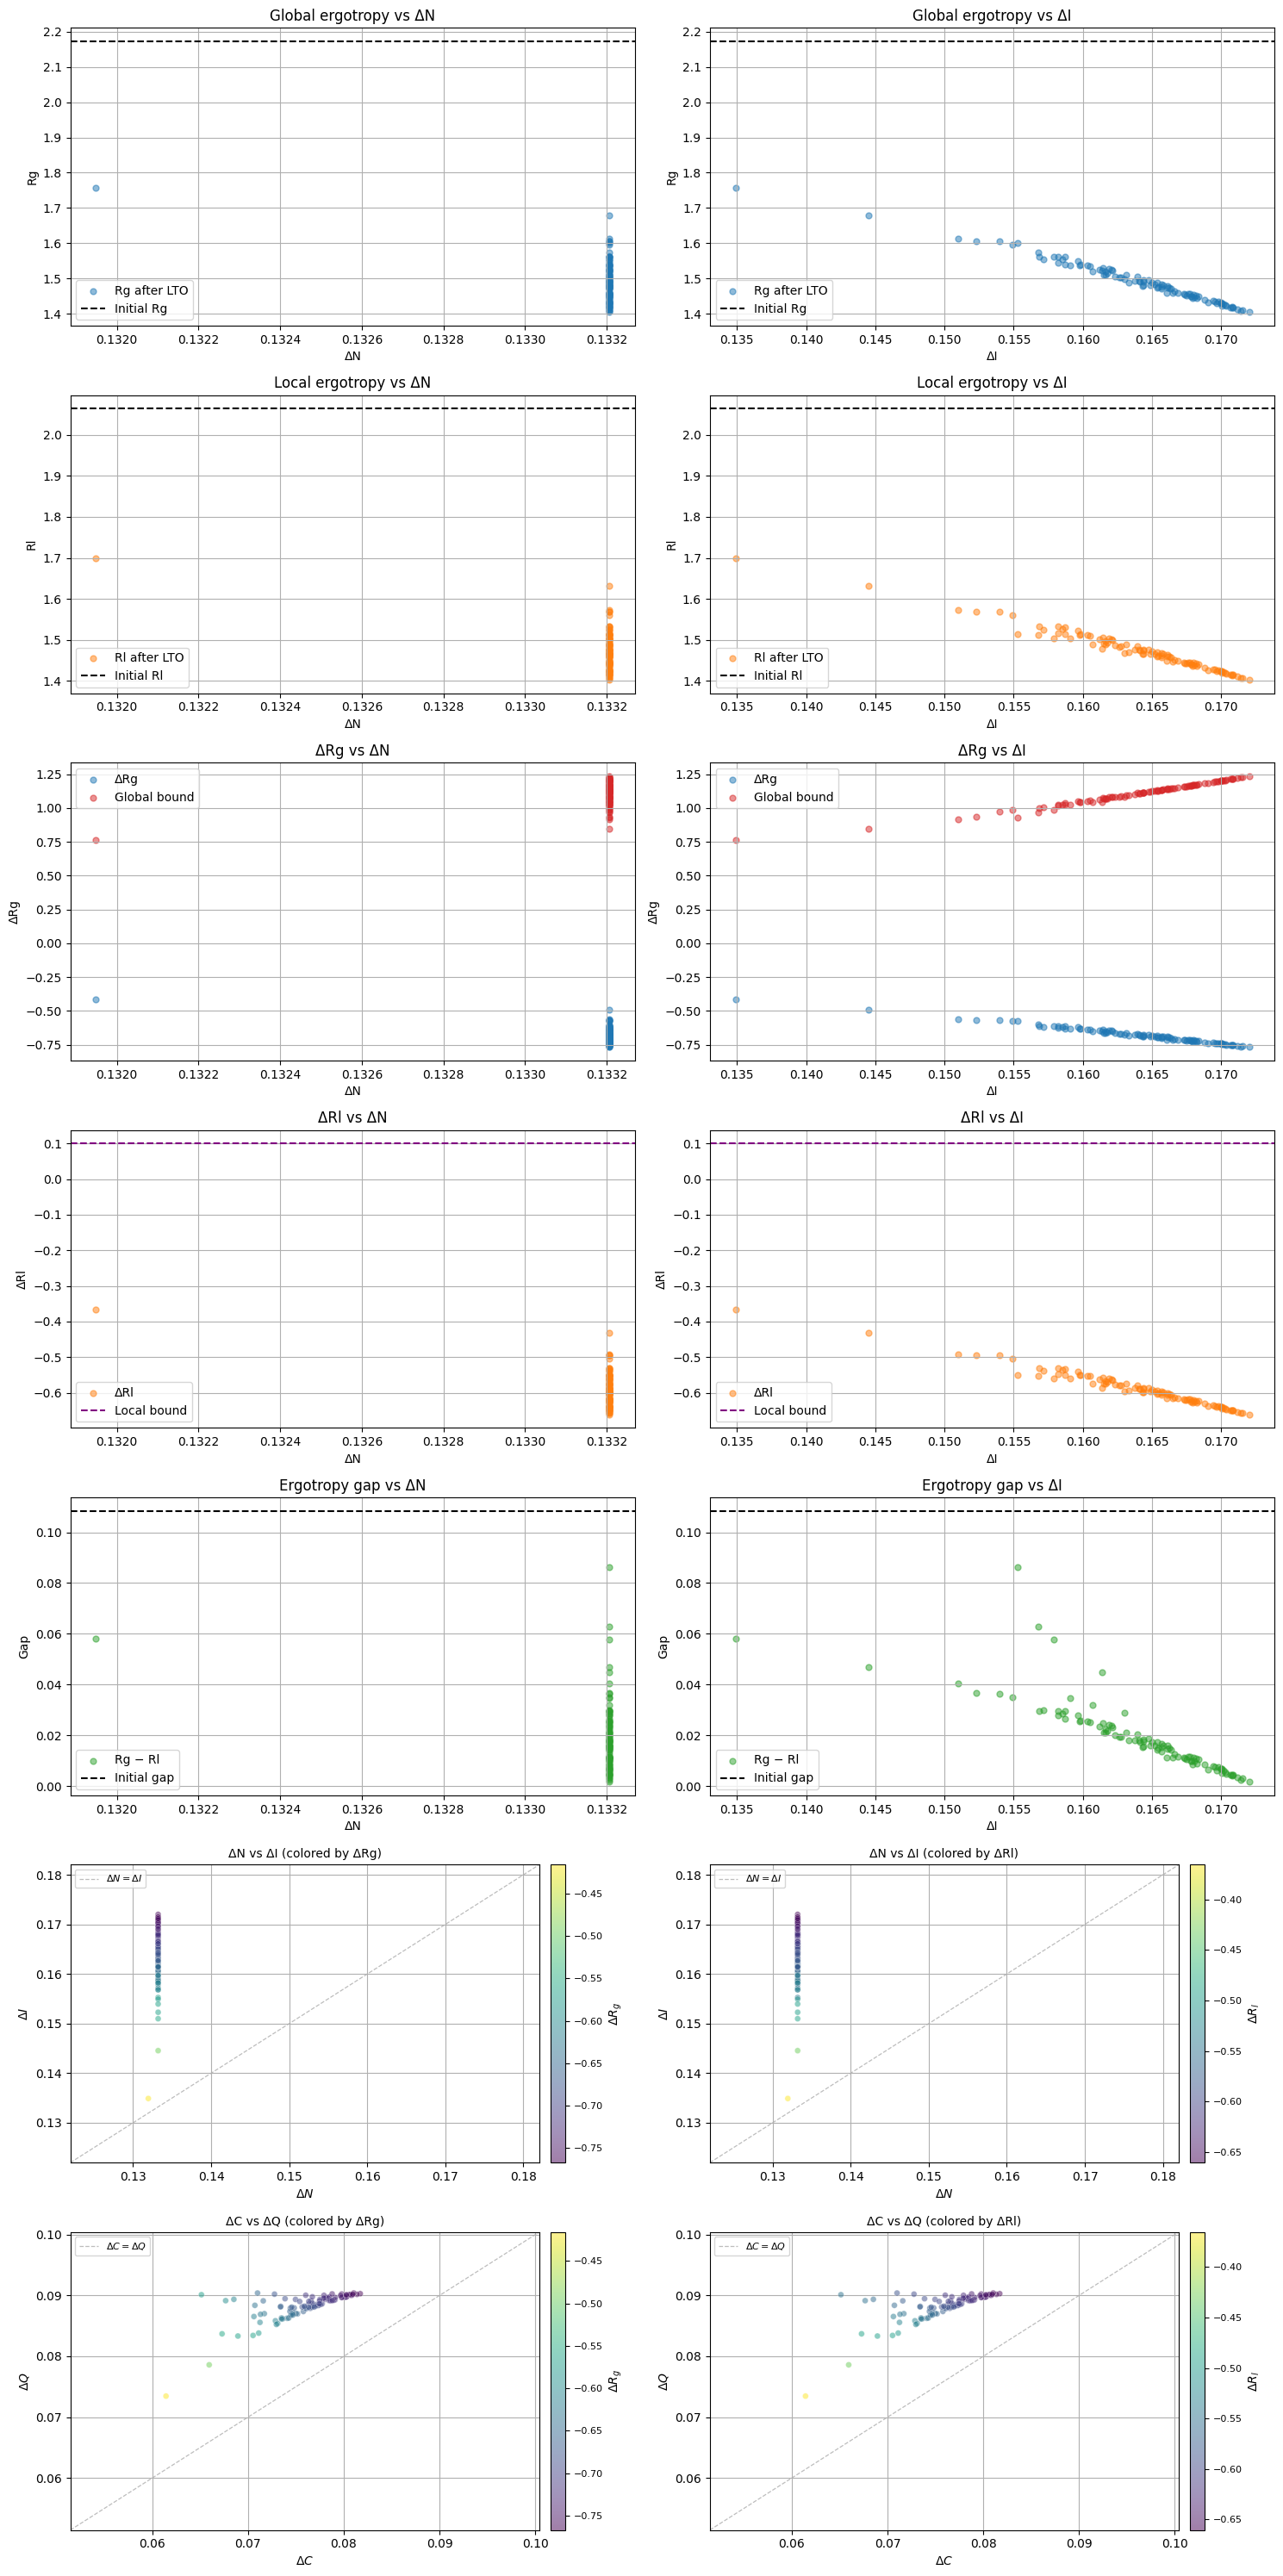

In [ ]:
# Run simulation and plot results
(rho12, neg_rho, mi_rho, Rg0, Rl0, neg_list, mi_list, cl_corr_list, disc_list, Rg_lto, Rl_lto, R_gap,
gbound_list, bound_l) = simulate_and_plot(kind=kind_dict[4], n_samples=100, corr_plot=True)

print(f'rho12: \n{rho12}')
print(partial_trace(rho12, sys=1))
print(partial_trace(rho12, sys=0))

plot_lto_results(neg_rho, mi_rho, Rg0, Rl0, neg_list, mi_list, cl_corr_list, disc_list, Rg_lto, Rl_lto, R_gap, gbound_list, bound_l)